# Load modules

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
from shapely.geometry import Polygon

In [2]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [3]:
project_name='250323 70deg'
if not os.path.exists('plots/'+project_name):
    os.mkdir('plots/'+project_name)
if not os.path.exists('Processed data/'+project_name):
    os.mkdir('Processed data/'+project_name)
if not os.path.exists('Raw data/'+project_name):
    os.mkdir('Raw data/'+project_name)

# Load data

## Batch files

In [4]:
def read_batch_file(path):
    start = pl.read_csv(path).with_row_index().filter(pl.col('[Header]')=='[Batch Table]')['index'][0]+2
    nrows = int(pl.read_csv(path,
                skip_rows=start,has_header=False,n_rows=1)[0,0].split('\t')[-1])
    return pl.read_csv(path,
                skip_rows=start+1,has_header=True,n_rows=nrows,separator='\t')

In [5]:
b0 = read_batch_file('Processed data/batch files/240428-std curve.txt')
b1 = read_batch_file('Processed data/batch files/250321 QC.txt')
b2 = read_batch_file('Processed data/batch files/250323 sol.txt')

batch = pl.concat([b0,b1,b2])
batch

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data File,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard:(I)""",null,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.33pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…",0,null,2,9.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""B11""","""AB(M1-42) 70deg 45.5h 5uM_2""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_AB(M1-42) 70deg 45.…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_clean_001_08.lcd""",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B12""","""AB(M1-42) 70deg 45.5h 0.5uM_2""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_AB(M1-42) 70deg 45.…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null


In [6]:
batch=batch.rename({'Data File':'Data Filename'})

## UV

In [7]:
summary205 = pl.read_csv('Processed data/'+project_name+'/250323 UV reprocessed 260127.txt',
                         skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summary205

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str
1,"""250323 sol_none_001_01.lcd""","""Control""","""none""","""-1""",null,null,null,null,null,null,null,null,null,null,null,null
2,"""250323 sol_AB(M1-42) 70deg 45.…","""Unknown""","""AB(M1-42) 70deg 45.5h 10uM_1""","""B7""",4.445,392615.0,15.49,102481.0,null,null,null,4.2,4.6,0.08,1866.57,"""--"""
3,"""250323 sol_AB(M1-42) 70deg 45.…","""Unknown""","""AB(M1-42) 70deg 45.5h 5uM_1""","""B8""",4.387,1.771441e6,69.872,512266.0,null,null,null,4.125,4.6,0.06,12270.74,"""--"""
4,"""250323 sol_clean_001_04.lcd""","""Control""","""clean""","""-1""",null,null,null,null,null,null,null,null,null,null,null,null
5,"""250323 sol_AB(M1-42) 70deg 45.…","""Unknown""","""AB(M1-42) 70deg 45.5h 0.5uM_1""","""B9""",4.4,115859.0,4.575,29667.0,null,null,null,4.125,4.6,0.08,559.69,"""--"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
24,"""250321 QC_AB(M1-42)_001_03.lcd""","""Control""","""AB(M1-42)""","""A11""",4.447,287615.0,11.349,112708.0,null,null,null,4.2,4.63,0.05,2417.11,"""0.986"""
25,"""250321 QC_AB(M1-42)_001_04.lcd""","""Control""","""AB(M1-42)""","""A11""",4.45,300466.0,11.856,113999.0,null,null,null,4.2,4.63,0.05,2589.39,"""1.012"""
26,"""250321 QC_buffer (250319)_001_…","""Control""","""buffer (250319)""","""A12""",null,null,null,null,null,null,null,null,null,null,null,null


In [8]:
rc(35,20)

In [9]:
pl.concat([batch,summary205],how='align_full').drop_nulls('Inj. Volume')#.drop_nulls('Area')

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data Filename,Background,…,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
str,str,str,str,i64,str,str,str,str,i64,…,f64,f64,f64,f64,str,f64,f64,f64,f64,str
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250321 QC_clean_001_05.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_clean_001_04.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_clean_001_08.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_clean_001_11.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250321 QC_none_001_01.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250323 sol_none_001_01.lcd""",0,…,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A11""","""AB(M1-42)""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250321 QC_AB(M1-42)_001_03.lcd""",0,…,null,null,null,null,null,null,null,null,null,null


In [10]:
batch.columns

['Run Mode',
 'Tray Name',
 'Vial#',
 'Sample Name',
 'Sample ID',
 'Sample Type',
 'Analysis Type',
 'Method File',
 'Data Filename',
 'Background',
 'Background Data File',
 'Level#',
 'Inj. Volume',
 'ISTD Amt.',
 'Sample Amt.',
 'Dil. Factor',
 'System Check',
 'Report Output',
 'Report Format File',
 'User Prog.',
 'Action',
 'Data Comment',
 'AutoPurge',
 'Baseline Check',
 'Option 1',
 'Option 2',
 'Option 3',
 'Option 4',
 'Option 5',
 'Custom Parameters',
 'Auto Tuning',
 'Tuning File',
 'PsiPort Instrument Method File',
 'Summary Type',
 'Summary Report Format File',
 'Option 6',
 'Option 7',
 'Option 8',
 'Option 9',
 'Option 10',
 'System Suitability',
 'Multi Injection',
 'Barcode',
 'Sampler File',
 'Conc. Overrides']

In [11]:
summary205.columns

['',
 'Data Filename',
 'Sample Type',
 'Sample Name',
 'Vial#',
 'Ret. Time',
 'Area',
 'Conc.',
 'Height',
 'Std. Conc.',
 'Accuracy[%]',
 'Cal. Point',
 'Peak Start',
 'Peak End',
 'Quant. Limit(QL)',
 'S/N',
 'Tailing F.']

In [12]:
rc(30,15)

In [13]:
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [14]:
UV = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summary205.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.drop_nulls('Sample Type')#.drop_nulls('Method File')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
UV#.show(fmt_str_lengths=100)

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_clean_001_05.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_04.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_08.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_11.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_01.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_none_001_15.lcd""",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_none_001_01.lcd""","""Control""",4.488,201511.0,7.953,13160.0,4.358,4.655,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_03.lcd""","""Control""",4.447,287615.0,11.349,112708.0,4.2,4.63,null


In [15]:
UV.filter(pl.col('Sample Type')=='Unknown')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B10""","""AB(M1-42) 70deg 45.5h 10uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 10uM_2_001_06.lcd""","""Unknown""",4.397,668394.0,26.367,184095.0,4.125,4.6,null
"""B11""","""AB(M1-42) 70deg 45.5h 5uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 5uM_2_001_07.lcd""","""Unknown""",4.393,1.658442e6,65.415,484711.0,4.125,4.6,null
"""B12""","""AB(M1-42) 70deg 45.5h 0.5uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_2_001_09.lcd""","""Unknown""",4.403,92202.0,3.642,20691.0,4.125,4.6,null
"""B7""","""AB(M1-42) 70deg 45.5h 10uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 10uM_1_001_02.lcd""","""Unknown""",4.445,392615.0,15.49,102481.0,4.2,4.6,null
"""B8""","""AB(M1-42) 70deg 45.5h 5uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 5uM_1_001_03.lcd""","""Unknown""",4.387,1.771441e6,69.872,512266.0,4.125,4.6,null
"""B9""","""AB(M1-42) 70deg 45.5h 0.5uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_1_001_05.lcd""","""Unknown""",4.4,115859.0,4.575,29667.0,4.125,4.6,null
"""C1""","""buffer 70deg 45.5h""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_buffer 70deg 45.5h_001_10.lcd""","""Unknown""",4.365,16340.0,0.65,3992.0,4.19,4.6,null


## MS

In [16]:
summaryMS = pl.read_csv('Processed data/'+project_name+'/250323 MS reprocessed 260127.txt',
                        skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""250323 sol_none_001_01.lcd""","""Control""","""none""","""-1""",null,null,…,null,null,null,null,null,null,null
2,"""250323 sol_AB(M1-42) 70deg 45.5h 10uM_1_001_02.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 10uM_1""","""B7""",4.465,776376.0,…,null,null,4.267,5.467,1.52,102.91,"""1.323"""
3,"""250323 sol_AB(M1-42) 70deg 45.5h 5uM_1_001_03.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 5uM_1""","""B8""",4.404,3.181638e6,…,null,null,4.267,4.683,1.92,334.81,"""1.319"""
4,"""250323 sol_clean_001_04.lcd""","""Control""","""clean""","""-1""",4.41,5820.0,…,null,null,4.3,4.533,0.06,6.64,"""0.983"""
5,"""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_1_001_05.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 0.5uM_1""","""B9""",null,null,…,null,null,4.267,4.6,null,null,null
6,"""250323 sol_AB(M1-42) 70deg 45.5h 10uM_2_001_06.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 10uM_2""","""B10""",4.413,1.239759e6,…,null,null,4.233,5.55,2.22,112.62,"""1.356"""
7,"""250323 sol_AB(M1-42) 70deg 45.5h 5uM_2_001_07.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 5uM_2""","""B11""",4.41,2.960101e6,…,null,null,4.283,4.683,2.52,237.73,"""1.341"""
8,"""250323 sol_clean_001_08.lcd""","""Control""","""clean""","""-1""",null,null,…,null,null,null,null,null,null,null
9,"""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_2_001_09.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 0.5uM_2""","""B12""",null,null,…,null,null,4.267,4.6,null,null,null


In [17]:
MS = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summaryMS.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full').drop_nulls('Sample Type')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_clean_001_05.lcd""","""Control""",4.456,976.0,-0.057,231.0,4.4,4.517,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_04.lcd""","""Control""",4.41,5820.0,0.041,1328.0,4.3,4.533,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_08.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_11.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_03.lcd""","""Control""",4.461,719753.0,14.486,178217.0,4.35,4.7,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_04.lcd""","""Control""",4.462,701587.0,14.119,177246.0,4.35,4.7,null
"""A12""","""buffer (250319)""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_buffer (250319)_001_02.lcd""","""Control""",null,null,null,null,null,null,null


## Chromatograms

In [18]:
path='Raw data/'+project_name+'/All chromatograms/'
list_of_UV_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_UV_chrom.append(name)
list_of_UV_chrom.sort(reverse=True)

In [19]:
data_UV = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [20]:
pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

Time (min),Abs (µAu)
f64,i64
0.0,-935
0.00167,-935
0.00333,-941
0.005,-947
0.00667,-954
0.00833,-7
0.01,-16
0.01167,-24
0.01333,-31


In [21]:
data_MS = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [22]:
path='Raw data/240428 std curve/chromatograms/'
list_of_std_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_std_chrom.append(name)
list_of_std_chrom.sort(reverse=True)

In [23]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [24]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

# Plot integrations & Calculate areas

## UV

### Standard curve

In [25]:
UV['Sample Type'].unique()

Sample Type
str
null
"""Unknown"""
"""Control"""
"""Standard(Calc.Point)"""


In [26]:
stds = UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.088,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,0.079,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.394,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.375,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.405,26554.0,1.053,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.41,26119.0,1.036,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.4,680512.0,26.845,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.4,672593.0,26.533,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.4,82947.0,3.277,33894.0,4.135,4.567,3.0


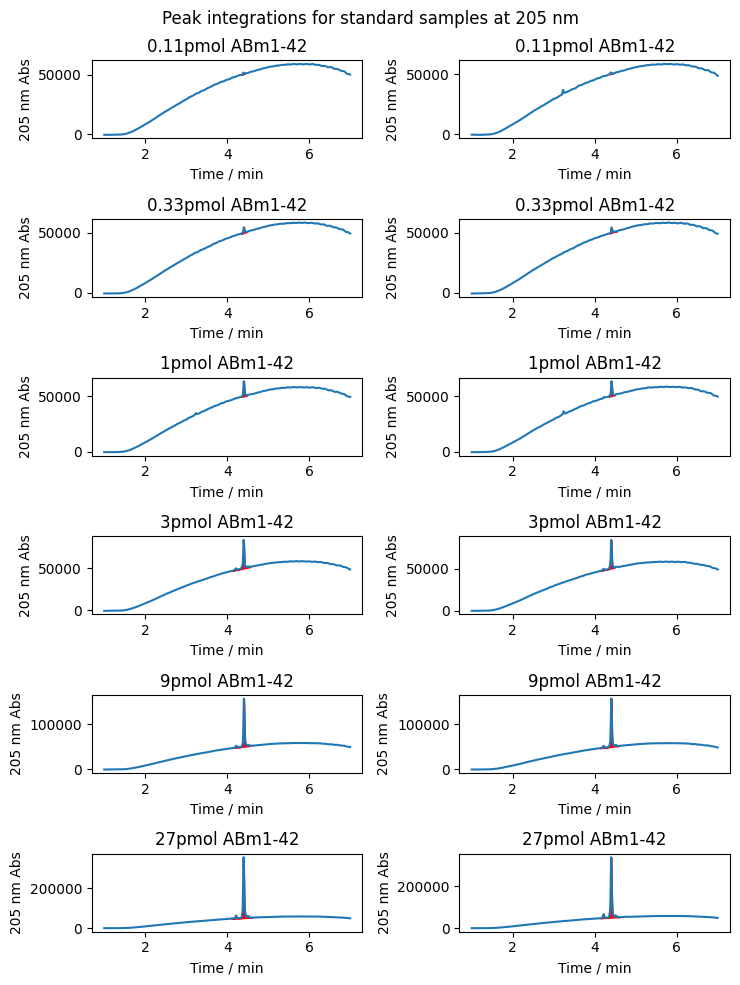

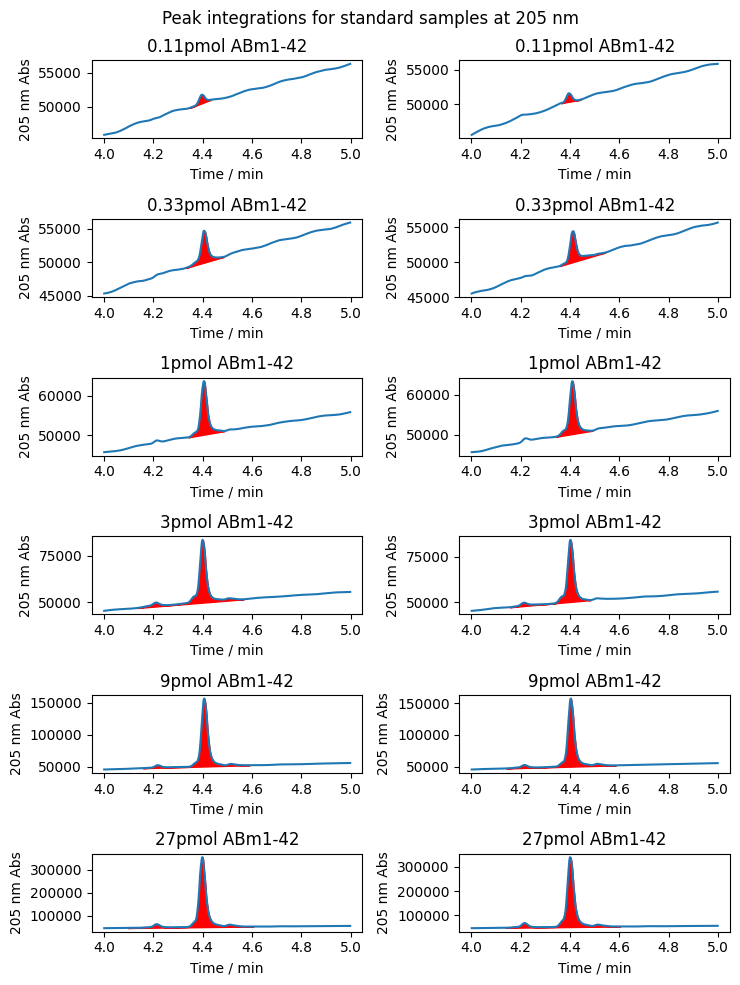

In [27]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for standard samples at 205 nm')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

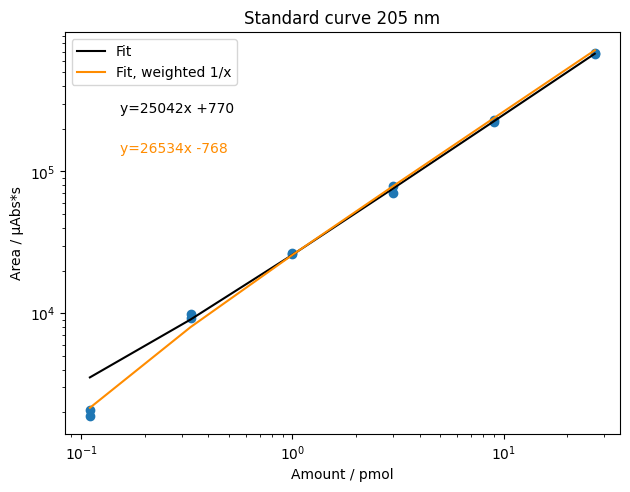

In [28]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / µAbs*s')
plt.tight_layout()
plt.title('Standard curve 205 nm')
std_curve_eq = fit_w

### Controls 

In [29]:
UV.filter(pl.col('Data Filename').str.contains('QC')
              ).filter(~pl.col('Vial#').str.contains('-1')
              )

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_03.lcd""","""Control""",4.447,287615.0,11.349,112708.0,4.2,4.63,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_04.lcd""","""Control""",4.45,300466.0,11.856,113999.0,4.2,4.63,null
"""A12""","""buffer (250319)""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_buffer (250319)_001_02.lcd""","""Control""",null,null,null,null,null,null,null


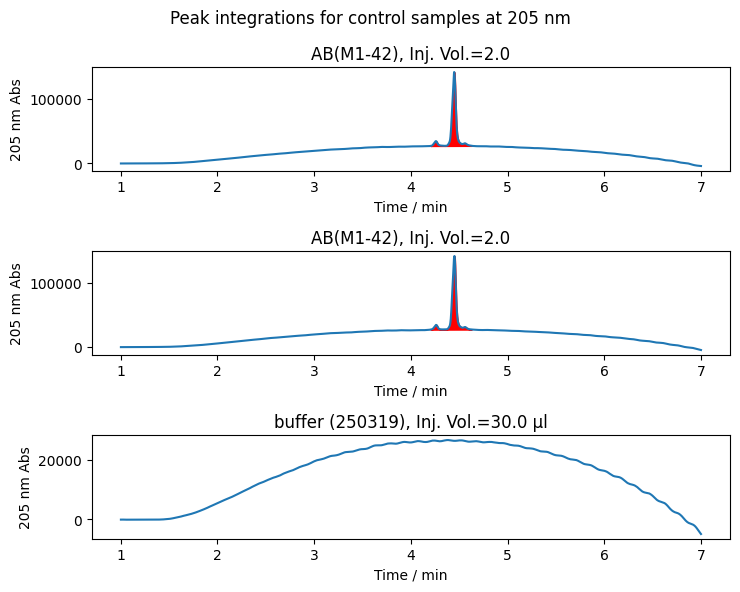

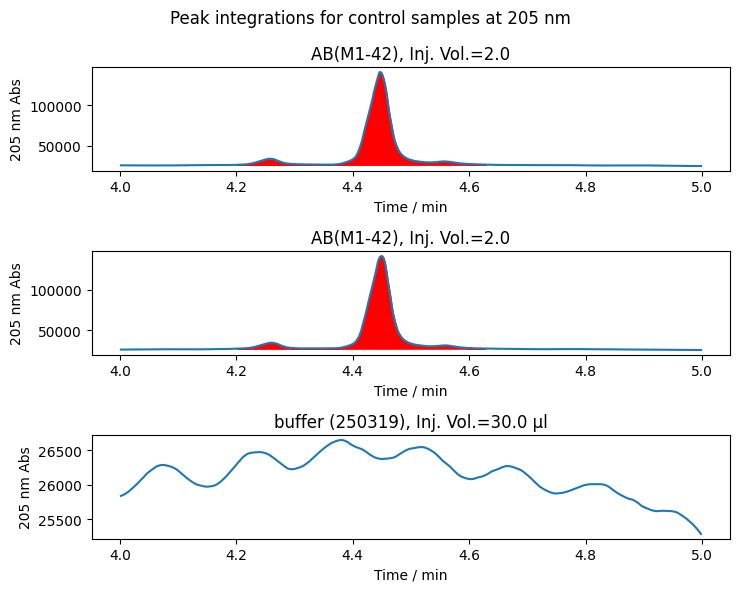

In [30]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(3,figsize=(7.5,6),sharey=False)

    for n,name in enumerate(UV.filter(pl.col('Data Filename').str.contains('QC')
                  ).filter(~pl.col('Vial#').str.contains('-1')
                  )['Data Filename']):
        if UV.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[n].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for control samples at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205 integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

In [31]:
UV.with_columns(
    pl.col('Conc.')/pl.col('Inj. Volume')
).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.397,2086.0,0.029333,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.395,1872.0,0.026333,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.407,9840.0,0.043778,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.412,9363.0,0.041667,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.405,26554.0,0.039,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.41,26119.0,0.03837,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.4,680512.0,0.994259,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.4,672593.0,0.982704,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.4,82947.0,1.092333,33894.0,4.135,4.567,3.0


In [32]:
UV.filter(pl.col('Sample Type')=="Unknown")

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B10""","""AB(M1-42) 70deg 45.5h 10uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 10uM_2_001_06.lcd""","""Unknown""",4.397,668394.0,26.367,184095.0,4.125,4.6,null
"""B11""","""AB(M1-42) 70deg 45.5h 5uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 5uM_2_001_07.lcd""","""Unknown""",4.393,1.658442e6,65.415,484711.0,4.125,4.6,null
"""B12""","""AB(M1-42) 70deg 45.5h 0.5uM_2""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_2_001_09.lcd""","""Unknown""",4.403,92202.0,3.642,20691.0,4.125,4.6,null
"""B7""","""AB(M1-42) 70deg 45.5h 10uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 10uM_1_001_02.lcd""","""Unknown""",4.445,392615.0,15.49,102481.0,4.2,4.6,null
"""B8""","""AB(M1-42) 70deg 45.5h 5uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 5uM_1_001_03.lcd""","""Unknown""",4.387,1.771441e6,69.872,512266.0,4.125,4.6,null
"""B9""","""AB(M1-42) 70deg 45.5h 0.5uM_1""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_1_001_05.lcd""","""Unknown""",4.4,115859.0,4.575,29667.0,4.125,4.6,null
"""C1""","""buffer 70deg 45.5h""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_buffer 70deg 45.5h_001_10.lcd""","""Unknown""",4.365,16340.0,0.65,3992.0,4.19,4.6,null


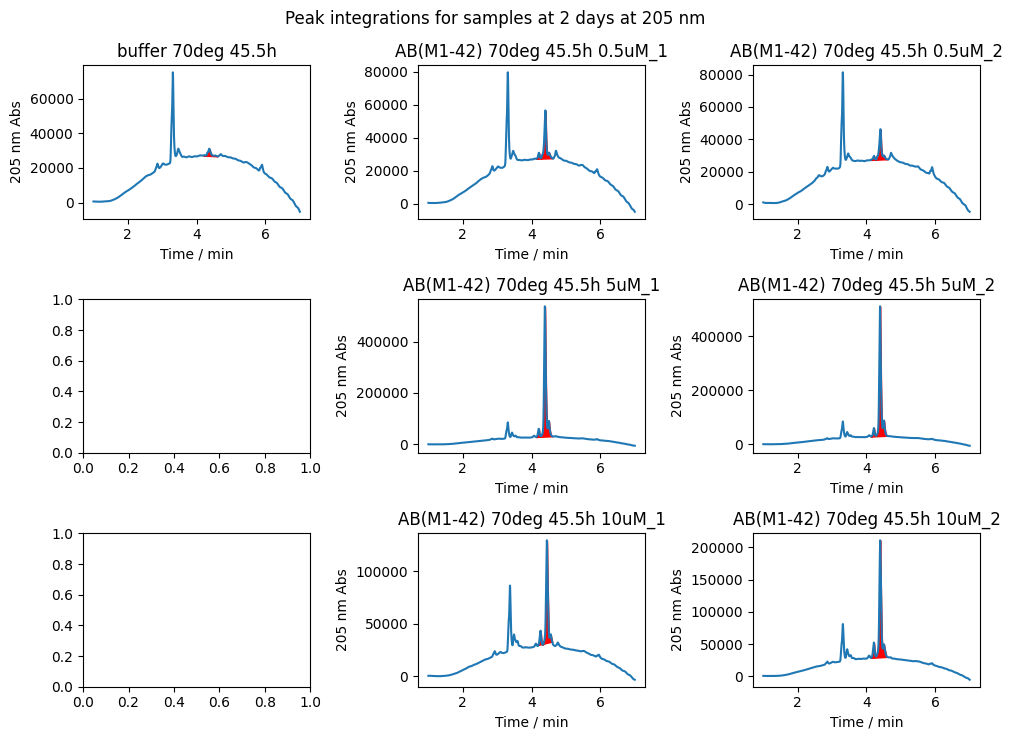

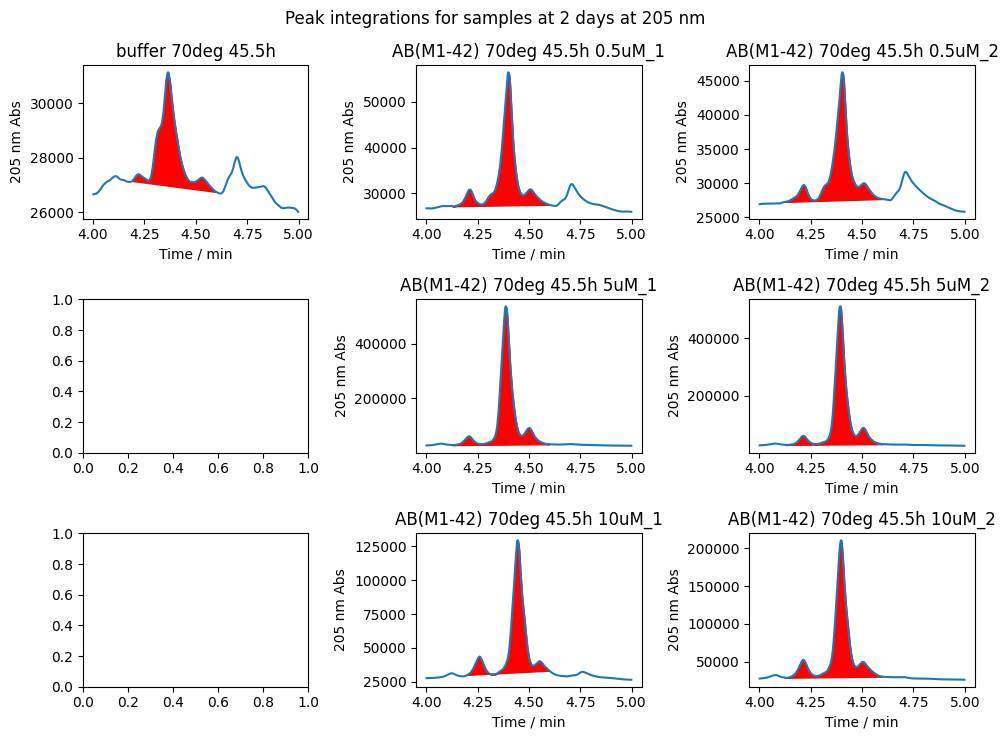

In [33]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
conc_to_row = {'0.5':0,
               '5':1,
               '10':2}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(3,3,figsize=(10,7.5),sharey=False)
    t_df = UV.filter(pl.col('Sample Type')=="Unknown"
     )
    
    for n,name in enumerate(t_df['Data Filename']):
        if t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0] != 'buffer 70deg 45.5h':
            if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
        
                chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
                peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
                peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
                df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                x=np.array([df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                       df.filter(pl.col('Time (min)')>peak_start
                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
                y=[df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
                slope, intercept = np.polyfit(x, y, 1)
                baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
                i=conc_to_row[t_df.filter(pl.col('Data Filename')==name
                 )['Sample Name'][0].split('uM')[0].split(' ')[-1]]
                j=int(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][-1])
              
                axs[i,j].plot(df['Time (min)'],
                         df['Abs (µAu)'])
                poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                                 df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                                baseline,color='red')
                paths = poly_collect.get_paths()
                area = 0
                for path in paths:
                    poly = Polygon(path.vertices)
                    area += poly.area
                areas.append(area*60) # to get it in µAbs*s as in Labsolutions
                names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
                axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])

            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                       df.filter(pl.col('Time (min)')>peak_start
                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            i=0
            j=0
            axs[i,j].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                                 df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                                baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
        
            axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for samples at 2 days at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for samples at 2 days-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [34]:
amounts_UV= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_UV_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [35]:
amounts_UV

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""AB(M1-42) 70deg 45.5h 10uM_2""",788106.830685,30.0,29.730499
"""AB(M1-42) 70deg 45.5h 5uM_2""",1.8869e6,30.0,71.141979
"""AB(M1-42) 70deg 45.5h 0.5uM_2""",93203.459475,30.0,3.541532
"""AB(M1-42) 70deg 45.5h 10uM_1""",393886.0698,30.0,14.87342
"""AB(M1-42) 70deg 45.5h 5uM_1""",2.0311e6,30.0,76.575006
"""AB(M1-42) 70deg 45.5h 0.5uM_1""",133265.051235,30.0,5.051341
"""buffer 70deg 45.5h""",24276.704502,30.0,0.943875
"""AB(M1-42)""",335669.305212,2.0,12.679392
"""AB(M1-42)""",336168.925746,2.0,12.698222


In [36]:
concs_UV=amounts_UV.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_UV


Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""AB(M1-42) 70deg 45.5h 10uM_2""",788106.830685,30.0,29.730499,991.016642
"""AB(M1-42) 70deg 45.5h 5uM_2""",1.8869e6,30.0,71.141979,2371.399306
"""AB(M1-42) 70deg 45.5h 0.5uM_2""",93203.459475,30.0,3.541532,118.051058
"""AB(M1-42) 70deg 45.5h 10uM_1""",393886.0698,30.0,14.87342,495.780655
"""AB(M1-42) 70deg 45.5h 5uM_1""",2.0311e6,30.0,76.575006,2552.500188
"""AB(M1-42) 70deg 45.5h 0.5uM_1""",133265.051235,30.0,5.051341,168.378042
"""buffer 70deg 45.5h""",24276.704502,30.0,0.943875,31.462494
"""AB(M1-42)""",335669.305212,2.0,12.679392,6339.696183
"""AB(M1-42)""",336168.925746,2.0,12.698222,6349.110835


In [37]:
corr_factor = (10000/
concs_UV.filter(pl.col('Sample Name')=="AB(M1-42)"
                ).mean()['Conc. (nM)'][0])
corr_factor

1.5761923064894423

In [38]:
concs_UV=concs_UV.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

In [39]:
concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('10uM')
                            )['Corr. Conc. (nM)'].to_numpy()

array([1562.03280663,  781.44565422])

In [40]:
concs_UV.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM),Corr. Conc. (nM)
str,f64,f64,f64,f64,f64
"""buffer 70deg 45.5h""",24276.704502,30.0,0.943875,31.462494,49.590941


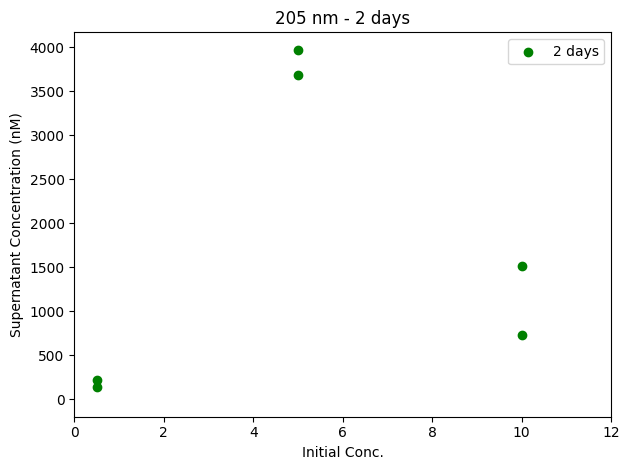

In [41]:
conces=['0.5uM',' 5uM','10uM']
buffer_corr_t1=[]
#buffer_corr_t2=[]
temps_t1=[]
#temps_t2=[]

for conc in conces:
    y_t1=(concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains(conc)
                            )['Corr. Conc. (nM)']
           -concs_UV.filter(pl.col('Sample Name').str.contains('buffer'))['Corr. Conc. (nM)'])
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    buffer_corr_t1.append(y_t1)
    #temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([float(conc.split('uM')[0])]*len(y_t1),y_t1,color='green')
    
    

UV_values = pl.DataFrame({'Temp':[70]*len(buffer_corr_t1),
                                           'Conc (nM)':buffer_corr_t1,
                                           'Incubation time (days)':[2]*len(buffer_corr_t1)
                                          })
plt.scatter(-10,0,color='green',label='2 days')
#plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(0,12)
plt.legend()
plt.xlabel('Initial Conc.')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - 2 days')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates-buffer and control sample corr.pdf')

In [42]:
UV_values[2,:] # only use 10 µM as 0.5 µM is below solubility from start and 5 µM is not yet aggregated

Temp,Conc (nM),Incubation time (days)
i64,"array[f64, 2]",i64
70,"[1512.441866, 731.854713]",2


In [43]:
UV_values[2,:].explode(['Conc (nM)']).write_csv('Processed data/'+project_name+'/UV values 260127.csv')

## MS

### Standard curve

In [44]:
stds = MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_03.lcd""","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.11pmol ABm1-42_001_04.lcd""","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_05.lcd""","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.367,4.567,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_0.33pmol ABm1-42_001_06.lcd""","""Standard(Calc.Point)""",4.426,21744.0,0.364,6361.0,4.333,4.567,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_07.lcd""","""Standard(Calc.Point)""",4.42,66732.0,1.274,19359.0,4.35,4.7,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_1pmol ABm1-42_001_08.lcd""","""Standard(Calc.Point)""",4.426,60146.0,1.141,16968.0,4.35,4.583,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_13.lcd""","""Standard(Calc.Point)""",4.416,1.308549e6,26.4,369996.0,4.283,4.7,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_27pmol ABm1-42_001_14.lcd""","""Standard(Calc.Point)""",4.417,1.288584e6,25.996,378560.0,4.35,4.7,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""240428-std curve_3pmol ABm1-42_001_09.lcd""","""Standard(Calc.Point)""",4.418,154879.0,3.057,44843.0,4.35,4.667,3.0


In [45]:
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""250323 sol_none_001_01.lcd""","""Control""","""none""","""-1""",null,null,…,null,null,null,null,null,null,null
2,"""250323 sol_AB(M1-42) 70deg 45.5h 10uM_1_001_02.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 10uM_1""","""B7""",4.465,776376.0,…,null,null,4.267,5.467,1.52,102.91,"""1.323"""
3,"""250323 sol_AB(M1-42) 70deg 45.5h 5uM_1_001_03.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 5uM_1""","""B8""",4.404,3.181638e6,…,null,null,4.267,4.683,1.92,334.81,"""1.319"""
4,"""250323 sol_clean_001_04.lcd""","""Control""","""clean""","""-1""",4.41,5820.0,…,null,null,4.3,4.533,0.06,6.64,"""0.983"""
5,"""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_1_001_05.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 0.5uM_1""","""B9""",null,null,…,null,null,4.267,4.6,null,null,null
6,"""250323 sol_AB(M1-42) 70deg 45.5h 10uM_2_001_06.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 10uM_2""","""B10""",4.413,1.239759e6,…,null,null,4.233,5.55,2.22,112.62,"""1.356"""
7,"""250323 sol_AB(M1-42) 70deg 45.5h 5uM_2_001_07.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 5uM_2""","""B11""",4.41,2.960101e6,…,null,null,4.283,4.683,2.52,237.73,"""1.341"""
8,"""250323 sol_clean_001_08.lcd""","""Control""","""clean""","""-1""",null,null,…,null,null,null,null,null,null,null
9,"""250323 sol_AB(M1-42) 70deg 45.5h 0.5uM_2_001_09.lcd""","""Unknown""","""AB(M1-42) 70deg 45.5h 0.5uM_2""","""B12""",null,null,…,null,null,4.267,4.6,null,null,null


In [46]:
data_MS['240428-std curve_27pmol ABm1-42_001_13.txt_MS-TIC']

Time (min),Absolute Intensity,Relative Intensity
f64,i64,f64
0.5,4331,1.15
0.517,4415,1.18
0.533,4437,1.18
0.55,4411,1.18
0.567,4409,1.18
0.583,4453,1.19
0.6,4596,1.23
0.617,4769,1.27
0.633,4744,1.27


In [47]:
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_clean_001_05.lcd""","""Control""",4.456,976.0,-0.057,231.0,4.4,4.517,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_04.lcd""","""Control""",4.41,5820.0,0.041,1328.0,4.3,4.533,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_08.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_clean_001_11.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250323 sol_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_03.lcd""","""Control""",4.461,719753.0,14.486,178217.0,4.35,4.7,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_04.lcd""","""Control""",4.462,701587.0,14.119,177246.0,4.35,4.7,null
"""A12""","""buffer (250319)""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_buffer (250319)_001_02.lcd""","""Control""",null,null,null,null,null,null,null


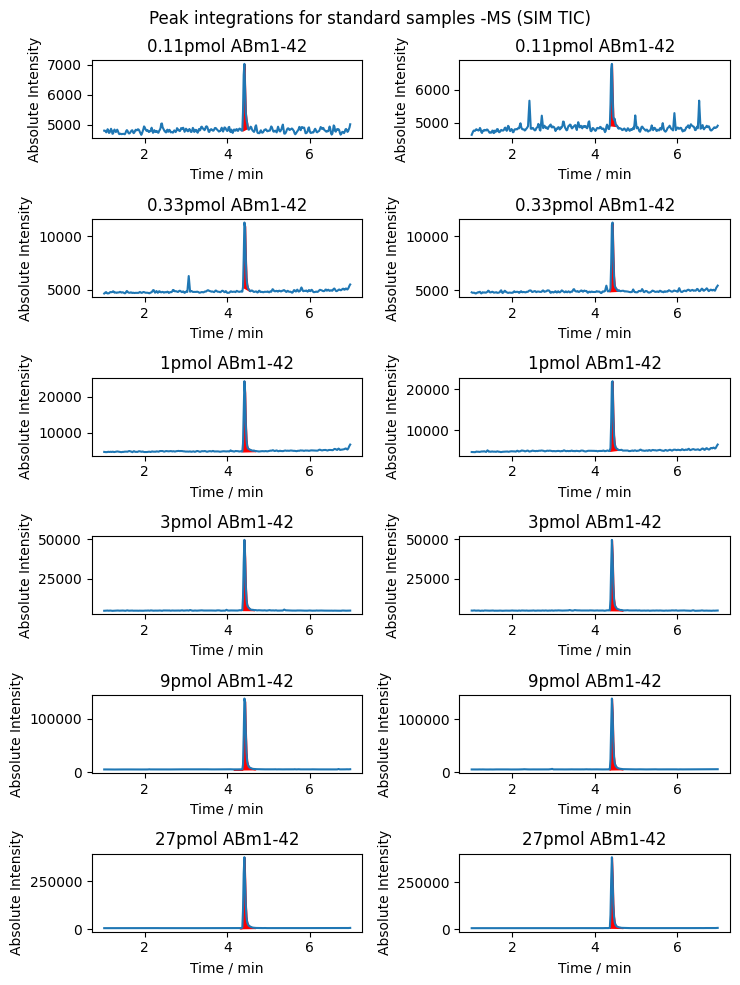

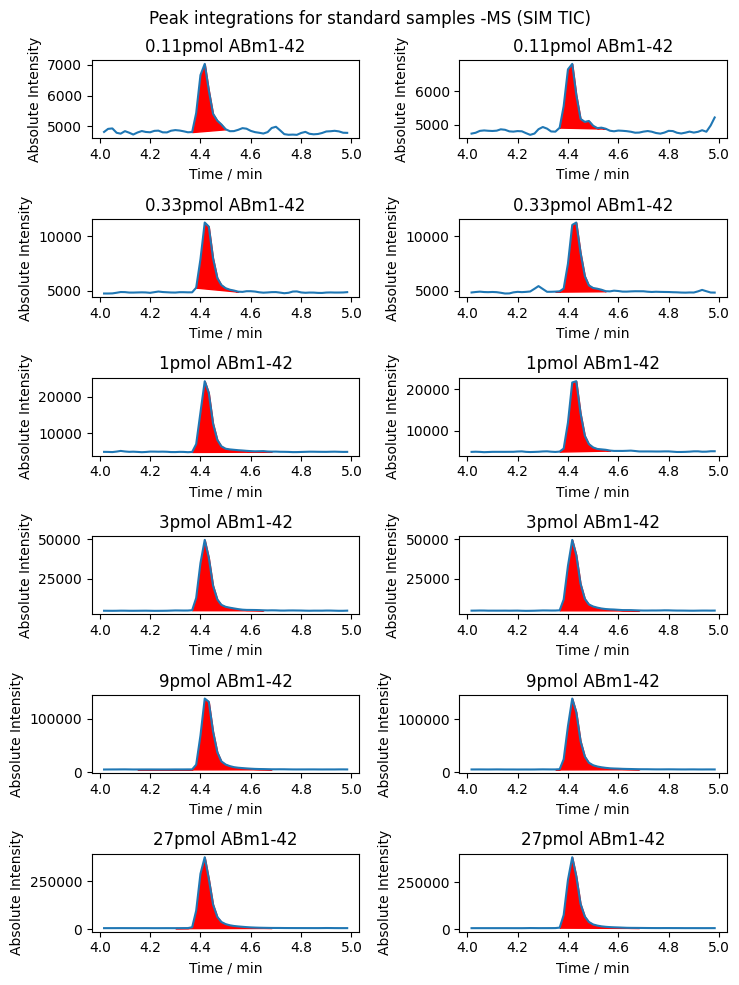

In [48]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in A.U.*s as in Labsolutions?
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for standard samples -MS (SIM TIC)')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

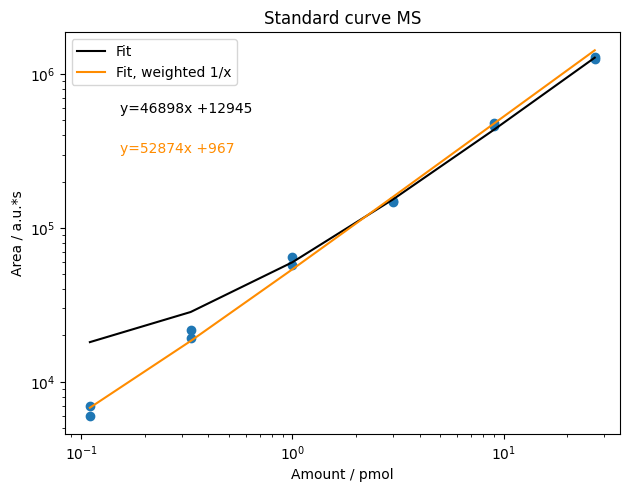

In [49]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x +'+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / a.u.*s')
plt.tight_layout()
plt.title('Standard curve MS')
std_curve_eq = fit_w

### Controls

In [50]:
MS.filter(pl.col('Data Filename').str.contains('QC')
              ).filter(~pl.col('Vial#').str.contains('-1')
              )

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_03.lcd""","""Control""",4.461,719753.0,14.486,178217.0,4.35,4.7,null
"""A11""","""AB(M1-42)""",2.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_AB(M1-42)_001_04.lcd""","""Control""",4.462,701587.0,14.119,177246.0,4.35,4.7,null
"""A12""","""buffer (250319)""",30.0,"""C:\LabSolutions\Data\Max\BioShell_AB(M1-42)_MS_QC+Quant.lcm""","""250321 QC_buffer (250319)_001_02.lcd""","""Control""",null,null,null,null,null,null,null


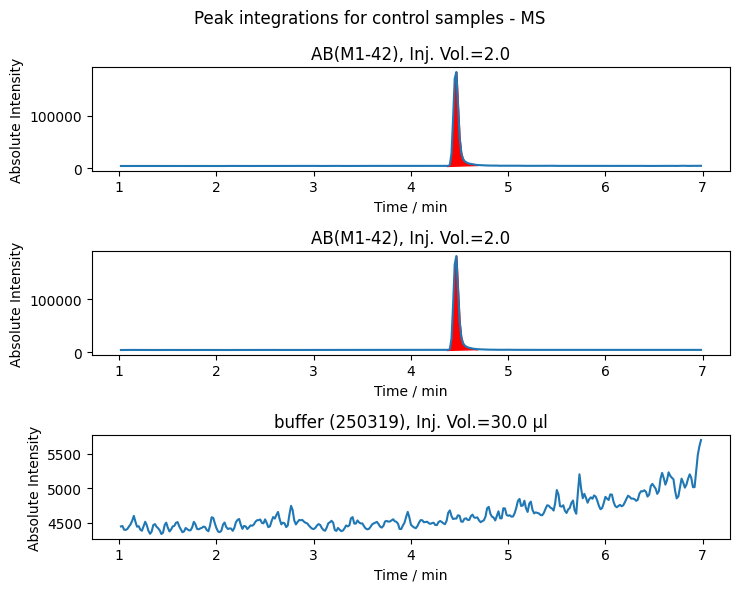

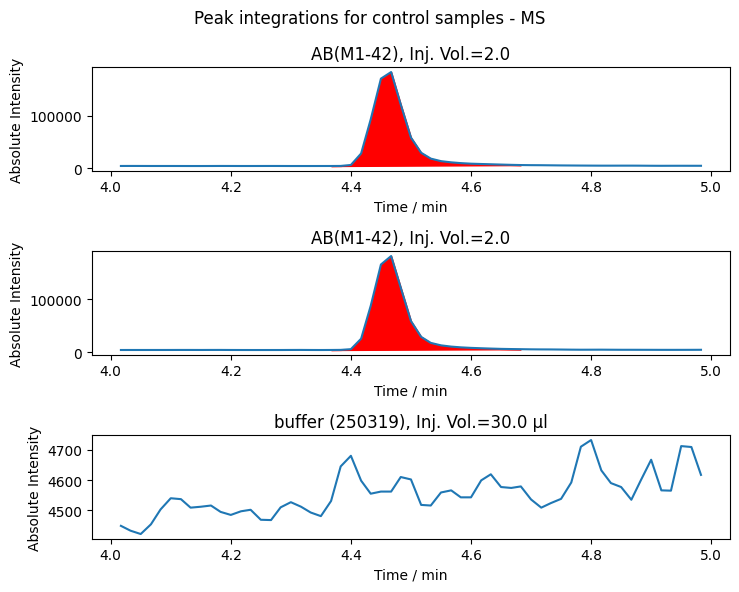

In [51]:

for zoom in [(1,7),(4,5)]:
    control_areas = []
    control_names = []
    control_inj_vols = []
    fig, axs = plt.subplots(3,figsize=(7.5,6),sharey=False)

    for n,name in enumerate(MS.filter(pl.col('Data Filename').str.contains('QC')
                  ).filter(~pl.col('Vial#').str.contains('-1')
                  )['Data Filename']):
        if MS.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[n].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            control_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            control_names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            control_inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])

            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0]))
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            # i=[int(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1] if UV.filter(pl.col('Data Filename')==name)['Sample Name'][0
            #     ].split('_')[1]!='B' else 0)][0]
            # if '2d' in name:
            #     j=0
            # if '7d' in name:
            #     j=1
            axs[n].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[n].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0]+', Inj. Vol.='+
                            str(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])+' µl')
            axs[n].set_xlabel('Time / min')
            axs[n].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for control samples - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for controls zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')

### Samples

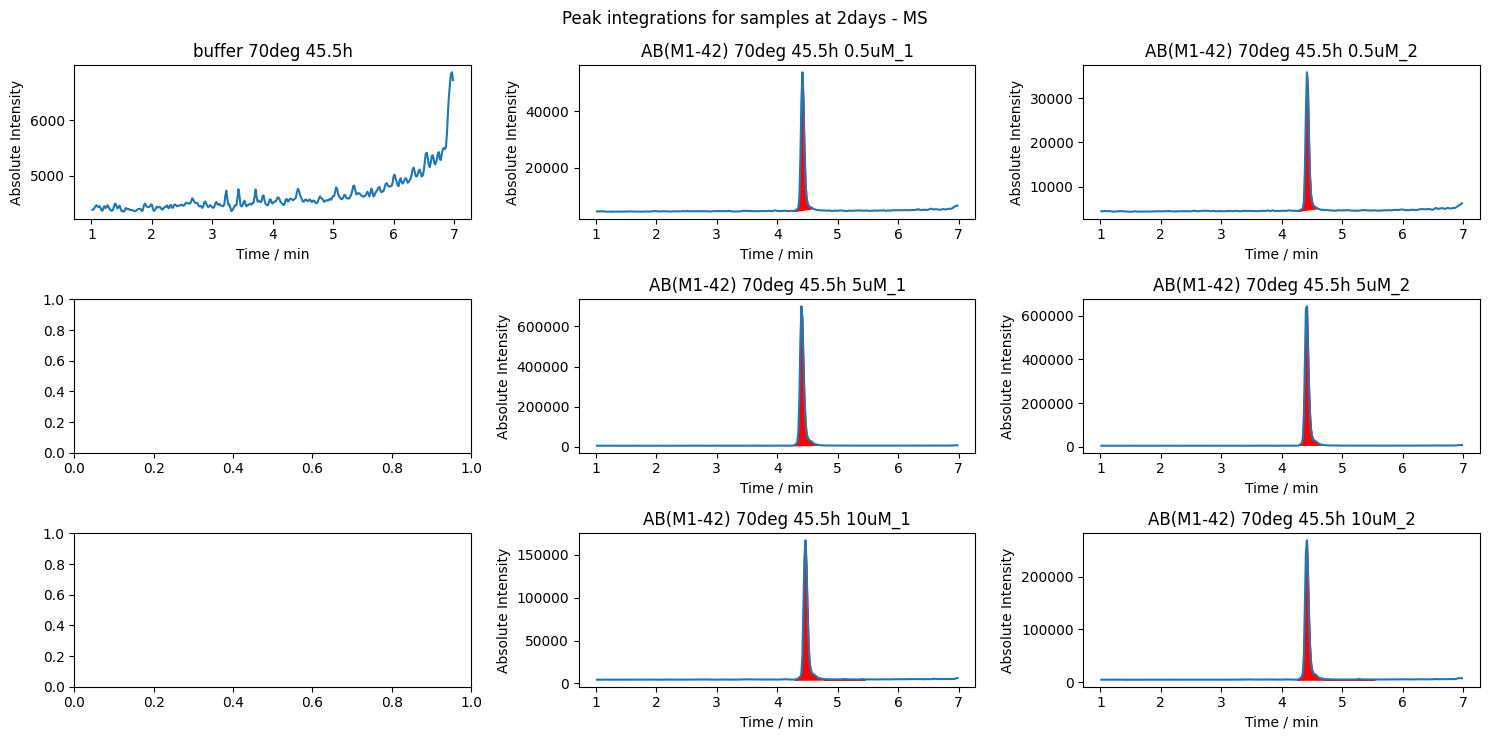

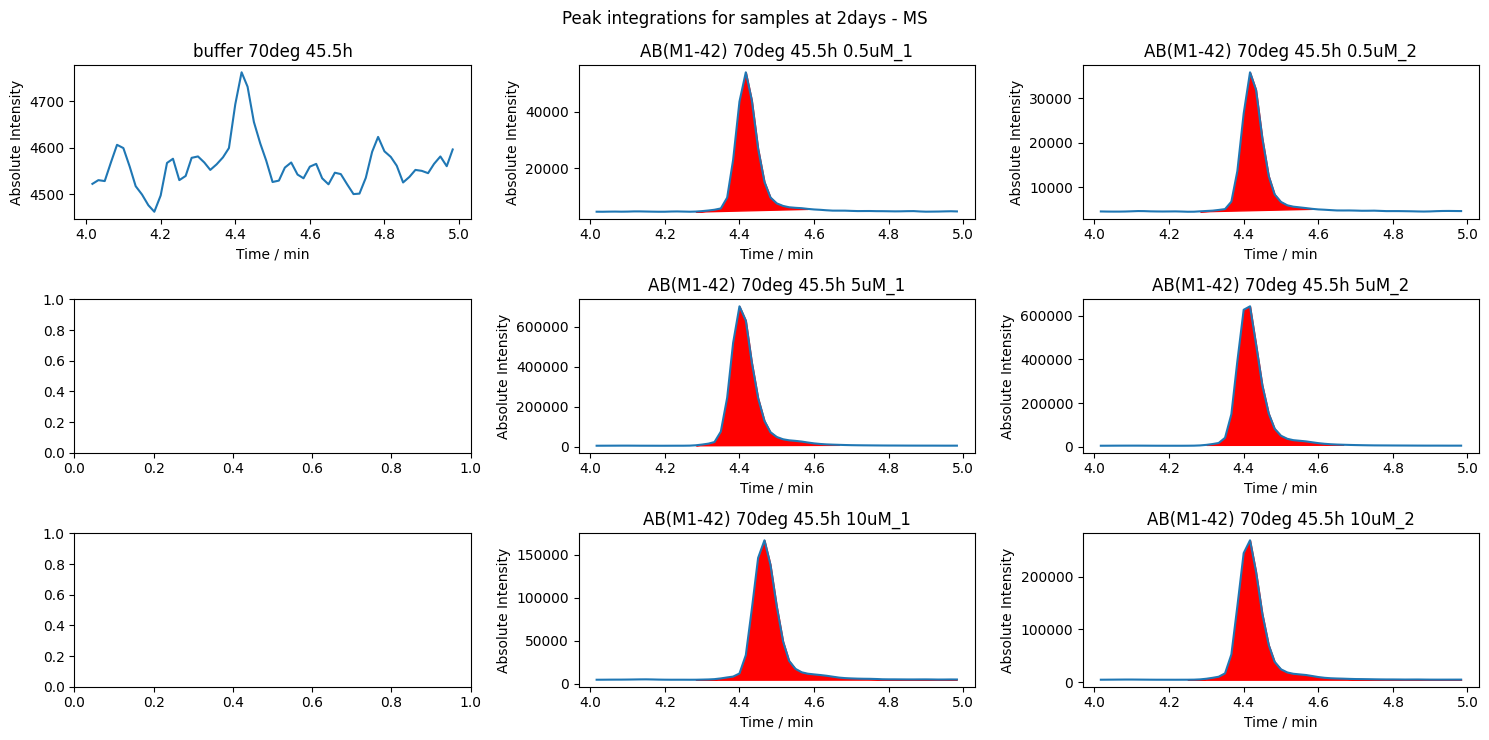

In [52]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
conc_to_row = {'0.5':0,
               '5':1,
               '10':2}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(3,3,figsize=(15,7.5),sharey=False)
    t_df = MS.filter(pl.col('Sample Type')=="Unknown"
     )
    
    for n,name in enumerate(t_df['Data Filename']):
        if t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0] != 'buffer 70deg 45.5h':

            if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
        
                chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
                peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
                peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
                df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                             ).filter(pl.col('Time (min)')<zoom[1])
                x=np.array([df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                       df.filter(pl.col('Time (min)')>peak_start
                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
                y=[df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
                slope, intercept = np.polyfit(x, y, 1)
                baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
                i=conc_to_row[t_df.filter(pl.col('Data Filename')==name
                 )['Sample Name'][0].split('uM')[0].split(' ')[-1]]
                j=int(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][-1])
              
                axs[i,j].plot(df['Time (min)'],
                         df['Absolute Intensity'])
                poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                                 df.filter(pl.col('Time (min)')>peak_start
                                             ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                                baseline,color='red')
                paths = poly_collect.get_paths()
                area = 0
                for path in paths:
                    poly = Polygon(path.vertices)
                    area += poly.area
                areas.append(area*60) # to get it in A.U.*s 
                names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
                axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
                axs[i,j].set_xlabel('Time / min')
                axs[i,j].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            i=0
            j=0
            axs[i,j].plot(df['Time (min)'],
                     df['Absolute Intensity'])
           
            
            axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for samples at 2days - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for samples at 2days -zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [53]:
amounts_MS= pl.DataFrame({'Sample Name':names+control_names,
                           'Area (python)':areas+control_areas,
                          'Inj. Vol.':inj_vols+control_inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_MS_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [54]:
amounts_MS

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""AB(M1-42) 70deg 45.5h 10uM_2""",1.2364e6,30.0,23.366293
"""AB(M1-42) 70deg 45.5h 5uM_2""",2.9215e6,30.0,55.235842
"""AB(M1-42) 70deg 45.5h 0.5uM_2""",122370.774,30.0,2.296095
"""AB(M1-42) 70deg 45.5h 10uM_1""",774628.164,30.0,14.632142
"""AB(M1-42) 70deg 45.5h 5uM_1""",3.1490e6,30.0,59.538571
"""AB(M1-42) 70deg 45.5h 0.5uM_1""",191934.114,30.0,3.611736
"""AB(M1-42)""",689889.498,2.0,13.029493
"""AB(M1-42)""",675028.95,2.0,12.748437


In [55]:
concs_MS=amounts_MS.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_MS#.filter(pl.col('Sample Name').str.contains('40')
                             #   )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""AB(M1-42) 70deg 45.5h 10uM_2""",1.2364e6,30.0,23.366293,778.876424
"""AB(M1-42) 70deg 45.5h 5uM_2""",2.9215e6,30.0,55.235842,1841.194719
"""AB(M1-42) 70deg 45.5h 0.5uM_2""",122370.774,30.0,2.296095,76.536491
"""AB(M1-42) 70deg 45.5h 10uM_1""",774628.164,30.0,14.632142,487.73808
"""AB(M1-42) 70deg 45.5h 5uM_1""",3.1490e6,30.0,59.538571,1984.619033
"""AB(M1-42) 70deg 45.5h 0.5uM_1""",191934.114,30.0,3.611736,120.391197
"""AB(M1-42)""",689889.498,2.0,13.029493,6514.746262
"""AB(M1-42)""",675028.95,2.0,12.748437,6374.218587


In [56]:
corr_factor = (10000/
concs_MS.filter(pl.col('Sample Name')=="AB(M1-42)"
                )['Conc. (nM)'][0])
corr_factor

1.5349791992584723

In [57]:
concs_MS=concs_MS.with_columns(
    (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
)

In [58]:
concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('70')
                            ).filter(pl.col('Sample Name').str.contains('10uM'))['Corr. Conc. (nM)'].to_numpy()

array([1195.55910994,  748.66780728])

In [59]:
# concs_MS.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

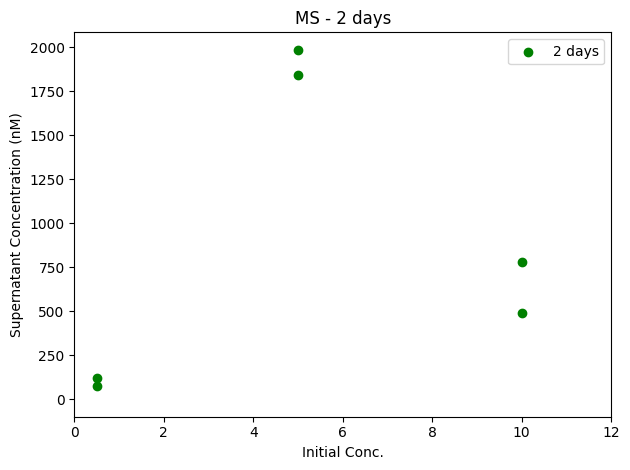

In [60]:
conces=['0.5uM',' 5uM','10uM']
t1=[]
#buffer_corr_t2=[]
temps_t1=[]
#temps_t2=[]

for conc in conces:
    y_t1=concs_MS.filter(pl.col('Sample Name').str.contains(conc)
                                        )['Conc. (nM)']#.to_numpy()
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    t1.append(y_t1)
    #temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([float(conc.split('uM')[0])]*len(y_t1),y_t1,color='green')
    
    

values = pl.DataFrame({'Temp':[70]*len(t1),
                                           'Conc (nM)':t1,
                                           'Incubation time (days)':[2]*len(t1)
                                          })
plt.scatter(-10,0,color='green',label='2 days')
#plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(0,12)
plt.legend()
plt.xlabel('Initial Conc.')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - 2 days')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates.pdf')

In [61]:
values[2,: # only use 10 µM as 0.5 µM is below solubility from start and 5 µM is not yet aggregated
]

Temp,Conc (nM),Incubation time (days)
i64,"array[f64, 2]",i64
70,"[778.876424, 487.73808]",2


In [62]:
values[2,: # only use 10 µM as 0.5 µM is below solubility from start and 5 µM is not yet aggregated
].explode(['Conc (nM)']).write_csv('Processed data/'+project_name+'/MS values 260127.csv')